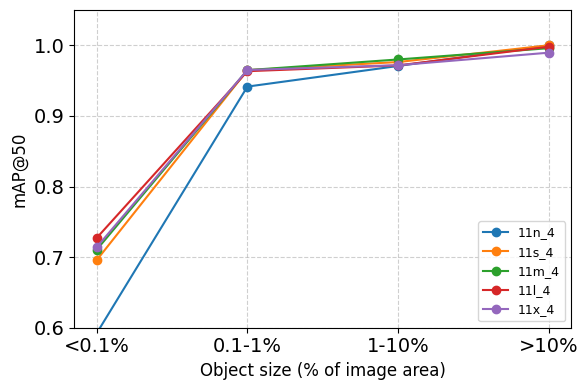

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Parámetros configurables
# ---------------------------
try:
    # Si corre como script .py
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Si corre en Jupyter Notebook
    BASE_DIR = os.getcwd()

PROJECT_ROOT = os.path.abspath(os.path.join(BASE_DIR, ".."))

csv_file = os.path.join(PROJECT_ROOT, "logs","Waid_mAP","WAID_mAP_intervalo_1.csv")

output_file = "mAP50_intervalo_1.pdf"

GRAPH_DIR = os.path.join(PROJECT_ROOT, "plots")
os.makedirs(GRAPH_DIR, exist_ok=True)


# ---------------------------
# Leer CSV
# ---------------------------
df = pd.read_csv(csv_file)

# Mapear intervalos a etiquetas de porcentaje
interval_to_pct = {
    1: "<0.1%",
    2: "0.1-1%",
    3: "1-10%",
    4: ">10%"
}
df["Tamaño"] = df["Intervalo"].map(interval_to_pct)

# Orden deseado para la leyenda
orden_modelos = ["11n_4", "11s_4", "11m_4", "11l_4", "11x_4"]

# ---------------------------
# Graficar
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 4))

line_styles = ["-", "--", "-.", ":"]  # estilos de línea disponibles
colors = ["blue", "green", "red", "orange", "purple"]  # colores para modelos

for modelo in orden_modelos:
    group = df[df["Modelo"] == modelo]
    ax.plot(group["Tamaño"], group["mAP@50"], marker="o", label=modelo)
    
    #linestyle=line_styles[i % len(line_styles)],
    #color=colors[i % len(colors)],


# Configuración de la gráfica
#ax.set_title("mAP@50 por tamaño de objeto", fontsize=14)
ax.set_xlabel("Object size (% of image area)", fontsize=12)
ax.set_ylabel("mAP@50", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.6)

# Leyenda en el orden deseado
handles, labels = ax.get_legend_handles_labels()
order = [labels.index(m) for m in orden_modelos if m in labels]
ax.legend([handles[i] for i in order],
          [labels[i] for i in order],
          loc="lower right",
          bbox_to_anchor=(1, 0),
          ncol=1,
          fontsize=9)
ax.set_ylim(0.6, 1.05)
ax.tick_params(axis='x', rotation=0, labelsize=14)
ax.tick_params(axis='y', rotation=0, labelsize=14)

# ---------------------------
# Guardar en PDF
# ---------------------------
pdf_path = os.path.join(GRAPH_DIR , output_file)
plt.tight_layout()
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

#print(f"Gráfica guardada en {pdf_path}")


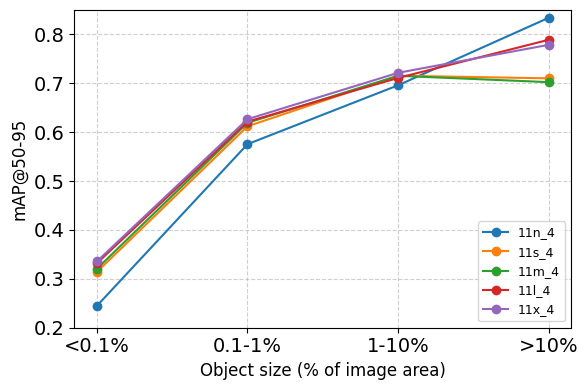

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Parámetros configurables
# ---------------------------
try:
    # Si corre como script .py
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Si corre en Jupyter Notebook
    BASE_DIR = os.getcwd()

PROJECT_ROOT = os.path.abspath(os.path.join(BASE_DIR, ".."))

csv_file = os.path.join(PROJECT_ROOT, "logs","Waid_mAP","WAID_mAP_intervalo_1.csv")

output_file = "mAP50-95_intervalo_1.pdf"

GRAPH_DIR = os.path.join(PROJECT_ROOT, "plots")
os.makedirs(GRAPH_DIR, exist_ok=True)


# ---------------------------
# Leer CSV
# ---------------------------
df = pd.read_csv(csv_file)

# Mapear intervalos a etiquetas de porcentaje
interval_to_pct = {
    1: "<0.1%",
    2: "0.1-1%",
    3: "1-10%",
    4: ">10%"
}
df["Tamaño"] = df["Intervalo"].map(interval_to_pct)

# Orden deseado para la leyenda
orden_modelos = ["11n_4", "11s_4", "11m_4", "11l_4", "11x_4"]

# ---------------------------
# Graficar
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 4))

line_styles = ["-", "--", "-.", ":"]  # estilos de línea disponibles
colors = ["blue", "green", "red", "orange", "purple"]  # colores para modelos

for modelo in orden_modelos:
    group = df[df["Modelo"] == modelo]
    ax.plot(group["Tamaño"], group["mAP@50-95"], marker="o", label=modelo)
    
    #linestyle=line_styles[i % len(line_styles)],
    #color=colors[i % len(colors)],


# Configuración de la gráfica
#ax.set_title("mAP@50 por tamaño de objeto", fontsize=14)
ax.set_xlabel("Object size (% of image area)", fontsize=12)
ax.set_ylabel("mAP@50-95", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.6)

# Leyenda en el orden deseado
handles, labels = ax.get_legend_handles_labels()
order = [labels.index(m) for m in orden_modelos if m in labels]
ax.legend([handles[i] for i in order],
          [labels[i] for i in order],
          loc="lower right",
          bbox_to_anchor=(1, 0),
          ncol=1,
          fontsize=9)
ax.set_ylim(0.2, 0.85)
ax.tick_params(axis='x', rotation=0, labelsize=14)
ax.tick_params(axis='y', rotation=0, labelsize=14)

# ---------------------------
# Guardar en PDF
# ---------------------------
pdf_path = os.path.join(GRAPH_DIR , output_file)
plt.tight_layout()
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

#print(f"Gráfica guardada en {pdf_path}")